In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [3]:
# Chargement des données à partir d'un fichier CSV
data = pd.read_csv("data-Clustering-Hiérarchique.csv")
print(data.head())   # afficher un extrait du dataset
print(data.info())   # le type de donnes etc 
print (data.describe()) # pour les dtatistiques du dataset

      dateRep  day  month  year    cases  deaths countriesAndTerritories  \
0  23/10/2022   23     10  2022   3557.0     0.0                 Austria   
1  22/10/2022   22     10  2022   5494.0     4.0                 Austria   
2  21/10/2022   21     10  2022   7776.0     4.0                 Austria   
3  20/10/2022   20     10  2022   8221.0     6.0                 Austria   
4  19/10/2022   19     10  2022  10007.0     8.0                 Austria   

  geoId countryterritoryCode  popData2020 continentExp  
0    AT                  AUT      8901064       Europe  
1    AT                  AUT      8901064       Europe  
2    AT                  AUT      8901064       Europe  
3    AT                  AUT      8901064       Europe  
4    AT                  AUT      8901064       Europe  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28729 entries, 0 to 28728
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------

In [ ]:
#######

In [46]:
# Calculer le nombre de pays et vérifier si chaque popData2020 correspond à un seul pays
unique_popData2020 = data.groupby('countriesAndTerritories')['popData2020'].nunique()
assert all(unique_popData2020 == 1), "Un pays a plusieurs valeurs de population."

# Nombre total de pays
nombre_pays = unique_popData2020.shape[0]
print(f"Nombre total de pays : {nombre_pays}")

# Afficher les pays et le nombre de lignes pour chaque pays
id_country = data[['countriesAndTerritories', 'popData2020']].drop_duplicates()
for index, row in id_country.iterrows():
    country = row['countriesAndTerritories']
    population = row['popData2020']
    lignes_par_pays = data[data['countriesAndTerritories'] == country].shape[0]
    print(f"Pays : {country}, Population : {population}, Nombre de Jours de suivis : {lignes_par_pays}")


Nombre total de pays : 30
Pays : Austria, Population : 8901064, Nombre de lignes : 971
Pays : Belgium, Population : 11522440, Nombre de lignes : 968
Pays : Bulgaria, Population : 6951482, Nombre de lignes : 962
Pays : Croatia, Population : 4058165, Nombre de lignes : 972
Pays : Cyprus, Population : 888005, Nombre de lignes : 794
Pays : Czechia, Population : 10693939, Nombre de lignes : 1003
Pays : Denmark, Population : 5822763, Nombre de lignes : 931
Pays : Estonia, Population : 1328976, Nombre de lignes : 973
Pays : Finland, Population : 5525292, Nombre de lignes : 1024
Pays : France, Population : 67320216, Nombre de lignes : 1006
Pays : Germany, Population : 83166711, Nombre de lignes : 992
Pays : Greece, Population : 10718565, Nombre de lignes : 971
Pays : Hungary, Population : 9769526, Nombre de lignes : 968
Pays : Iceland, Population : 364134, Nombre de lignes : 803
Pays : Ireland, Population : 4964440, Nombre de lignes : 962
Pays : Italy, Population : 59641488, Nombre de lignes :

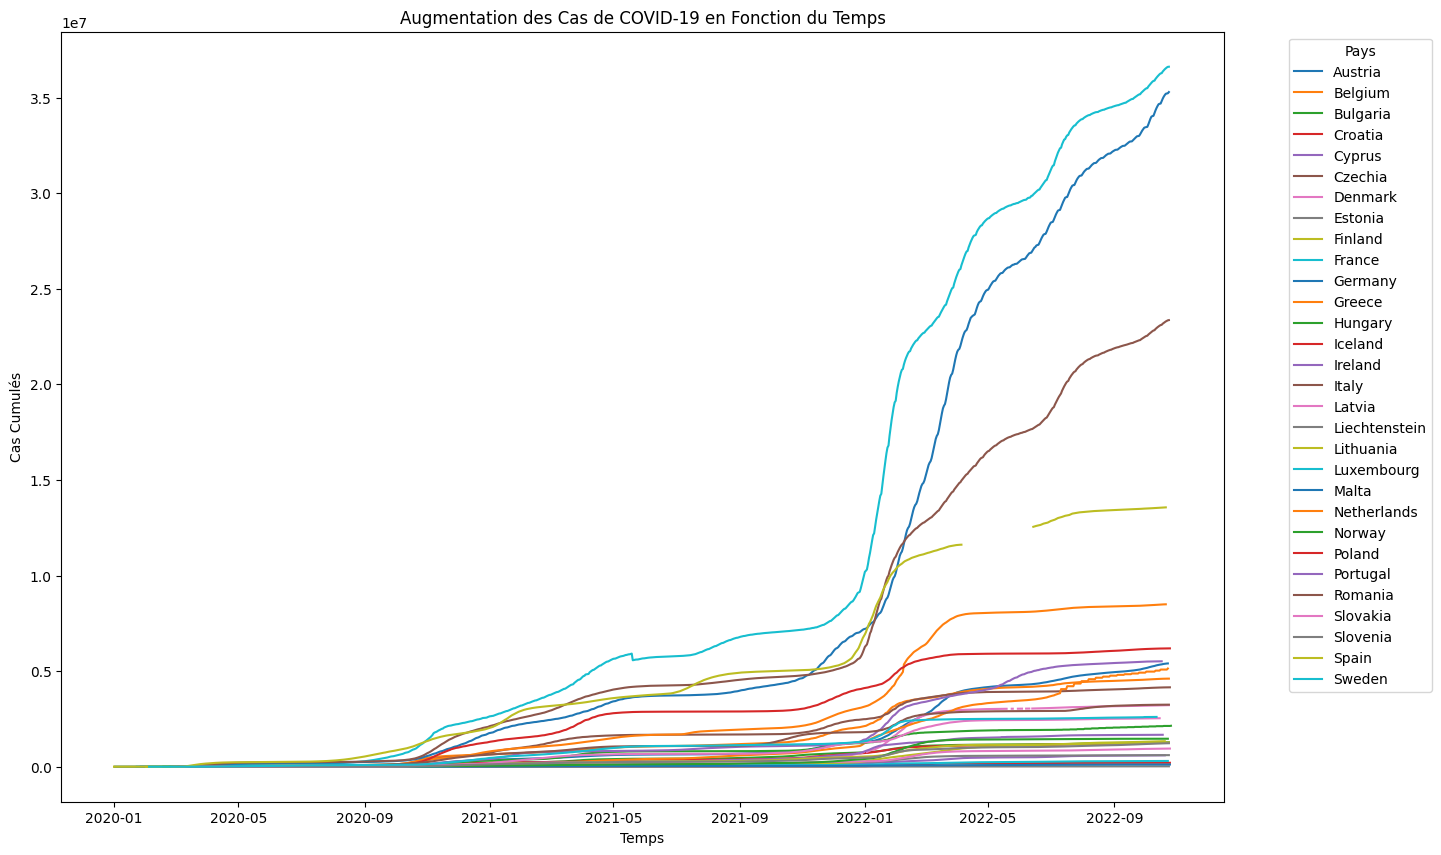

In [53]:
plt.figure(figsize=(15, 10))
for country in countries:
    country_data = data[data['countriesAndTerritories'] == country]
    plt.plot(country_data['dateRep'], country_data['cumulative_cases'], label=country)

plt.title("Augmentation des Cas de COVID-19 en Fonction du Temps")
plt.xlabel("Temps")
plt.ylabel("Cas Cumulés")
plt.legend(title='Pays', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [50]:
# Convertir la colonne dateRep en format datetime
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')

# Trouver la date maximale de début et la date minimale de fin pour chaque pays
start_dates = data.groupby('countriesAndTerritories')['dateRep'].min().max()
end_dates = data.groupby('countriesAndTerritories')['dateRep'].max().min()

# Filtrer les données pour les dates dans la plage commune
aligned_data = data[(data['dateRep'] >= start_dates) & (data['dateRep'] <= end_dates)]

# Affichage des dates debuts et fin 
print(f"Date du debut de l'analyse : {start_dates}, \nDate du fin de l'analyse : {end_dates}")


# Enregistrer le DataFrame aligné dans un CSV
aligned_data.to_csv("aligned_data.csv", index=False)
print(aligned_data.head())


Date du debut de l'analyse : 2020-03-14 00:00:00, 
Date du fin de l'analyse : 2022-10-12 00:00:00
      dateRep  day  month  year    cases  deaths countriesAndTerritories  \
11 2022-10-12   12     10  2022  14305.0    13.0                 Austria   
12 2022-10-11   11     10  2022  18498.0    11.0                 Austria   
13 2022-10-10   10     10  2022  13369.0    10.0                 Austria   
14 2022-10-09    9     10  2022   8689.0    10.0                 Austria   
15 2022-10-08    8     10  2022  11230.0    12.0                 Austria   

   geoId countryterritoryCode  popData2020 continentExp  
11    AT                  AUT      8901064       Europe  
12    AT                  AUT      8901064       Europe  
13    AT                  AUT      8901064       Europe  
14    AT                  AUT      8901064       Europe  
15    AT                  AUT      8901064       Europe  


In [10]:
from sklearn.preprocessing import MinMaxScaler

# Afficher les valeurs maximales et minimales des colonnes `cases` et `deaths`
max_cases = aligned_data['cases'].max()
min_cases = aligned_data['cases'].min()
max_deaths = aligned_data['deaths'].max()
min_deaths = aligned_data['deaths'].min()

print(f"Max cases: {max_cases}, Min cases: {min_cases}")
print(f"Max deaths: {max_deaths}, Min deaths: {min_deaths}")

# Normaliser les colonnes `cases` et `deaths`
def normalize_column(column):
    scaler = MinMaxScaler()
    normalized = scaler.fit_transform(column.values.reshape(-1, 1))
    return normalized.flatten()

aligned_data.loc[:, 'cases_normalized'] = normalize_column(aligned_data['cases'])
aligned_data.loc[:, 'deaths_normalized'] = normalize_column(aligned_data['deaths'])

# Afficher les colonnes normalisées
print(aligned_data[['cases_normalized', 'deaths_normalized']].head())

# Afficher les valeurs maximales et minimales des colonnes normalisee `cases` et `deaths`
max_cases = aligned_data['cases_normalized'].max()
min_cases = aligned_data['cases_normalized'].min()
max_deaths = aligned_data['deaths_normalized'].max()
min_deaths = aligned_data['deaths_normalized'].min()

print(f"Max cases nor: {max_cases}, Min cases nor: {min_cases}")
print(f"Max deaths nor: {max_deaths}, Min deaths nor: {min_deaths}")

Max cases: 501635.0, Min cases: -348846.0
Max deaths: 13743.0, Min deaths: -217.0
    cases_normalized  deaths_normalized
11          0.426995           0.016476
12          0.431925           0.016332
13          0.425894           0.016261
14          0.420392           0.016261
15          0.423379           0.016404
Max cases nor: 1.0, Min cases nor: 0.0
Max deaths nor: 1.0, Min deaths nor: 0.0


In [54]:
# Calculer le nombre total de cas et de morts pour chaque pays
country_all = aligned_data.groupby('countriesAndTerritories').agg({'cases': 'sum', 'deaths': 'sum'}).reset_index()

# Renommer les colonnes pour plus de clarté
country_all.columns = ['countriesAndTerritories', 'all_cases', 'all_deaths']
print(country_all.head())


  countriesAndTerritories  all_cases  all_deaths
0                 Austria  5303108.0     20819.0
1                 Belgium  4586056.0     32772.0
2                Bulgaria  1268004.0     37747.0
3                 Croatia  1239464.0     16994.0
4                  Cyprus   590769.0      1187.0


In [36]:
# Calculer le nombre total de cas et de morts pour chaque pays
country_totals = aligned_data.groupby('countriesAndTerritories').agg({'cases_normalized': 'sum', 'deaths_normalized': 'sum'}).reset_index()
country_totals.columns = ['countriesAndTerritories', 'total_cases', 'total_deaths']
country_totals['cases_deaths_sum'] = country_totals['total_cases'] + country_totals['total_deaths']

# Vérifier la présence de la colonne 'cases_deaths_sum'
print(country_totals.head())


  countriesAndTerritories  total_cases  total_deaths  cases_deaths_sum
0                 Austria   393.030398     16.149713        409.180112
1                 Belgium   392.187285     16.897135        409.084419
2                Bulgaria   388.285902     17.315688        405.601589
3                 Croatia   388.252344     15.875716        404.128061
4                  Cyprus   323.502313     12.318481        335.820795


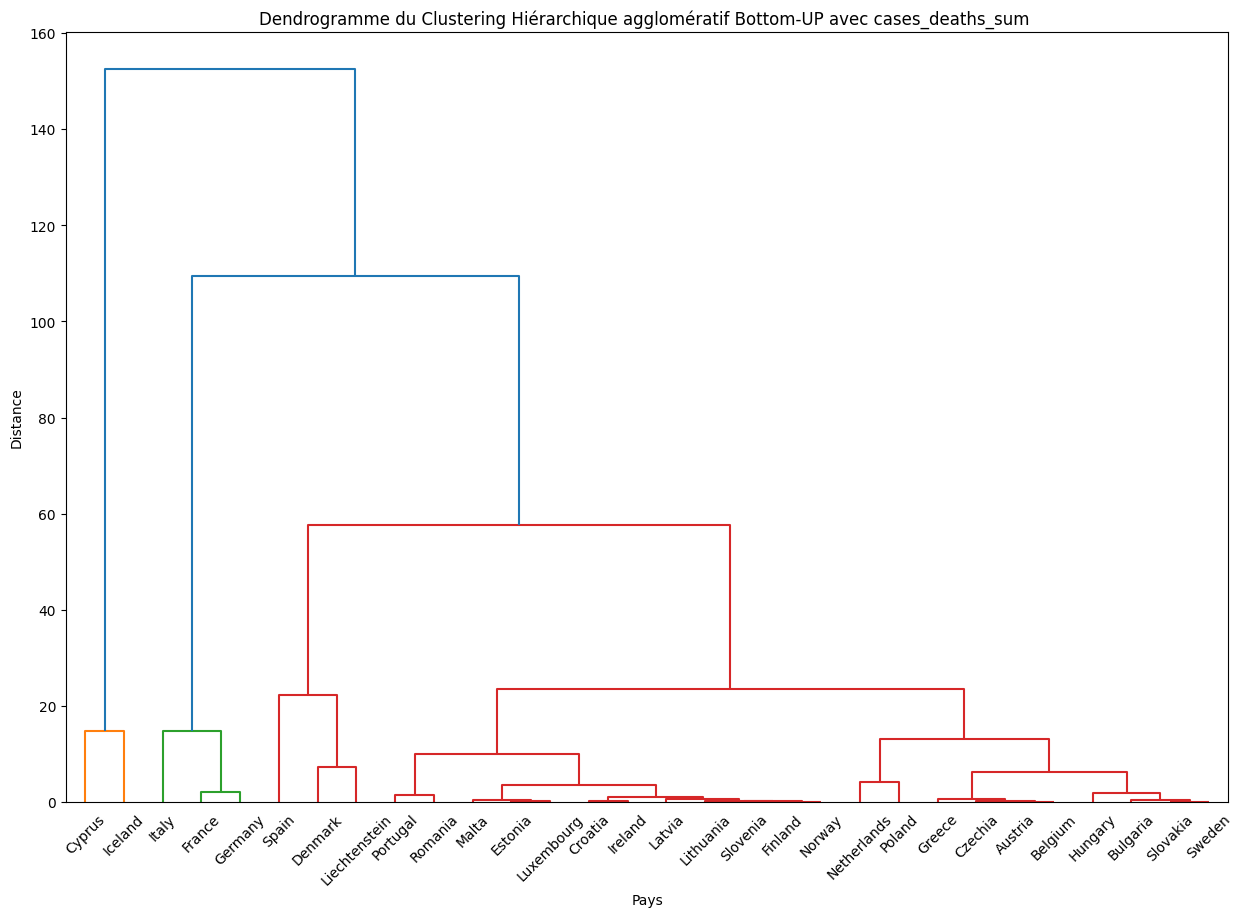

In [55]:
from scipy.cluster.hierarchy import dendrogram, linkage


# Initialisation des clusters avec chaque pays comme un cluster
linkage_matrix = linkage(country_totals[['cases_deaths_sum']], method='ward')

# Visualisation du dendrogramme
plt.figure(figsize=(15, 10))
dendrogram(linkage_matrix, labels=country_totals['countriesAndTerritories'].values)
plt.title("Dendrogramme du Clustering Hiérarchique agglomératif Bottom-UP avec cases_deaths_sum ")
plt.xlabel("Pays")
plt.ylabel("Distance")
plt.show()


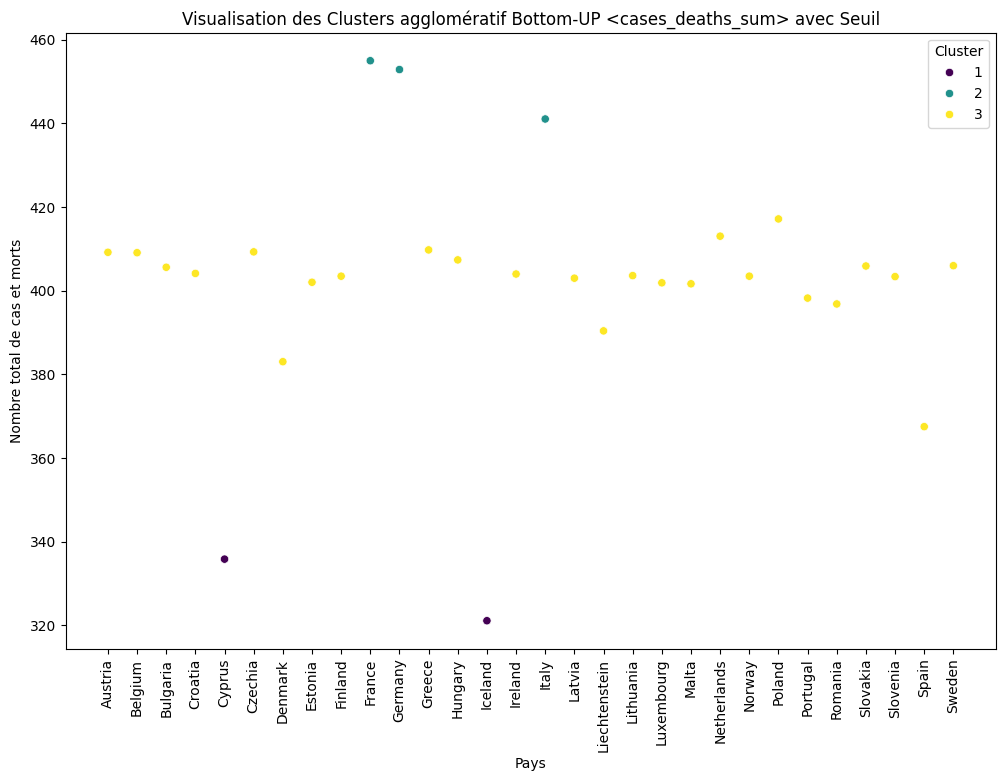

Cluster 3: {Austria, Belgium, Bulgaria, Croatia, Czechia, Denmark, Estonia, Finland, Greece, Hungary, Ireland, Latvia, Liechtenstein, Lithuania, Luxembourg, Malta, Netherlands, Norway, Poland, Portugal, Romania, Slovakia, Slovenia, Spain, Sweden}
Cluster 1: {Cyprus, Iceland}
Cluster 2: {France, Germany, Italy}


In [56]:
# Détermination des clusters avec un seuil (moitié du maximum des sommes)
max_distance = linkage_matrix[:, 2].max()  # Distance maximale dans le dendrogramme
seuil = max_distance / 2
clusters = fcluster(linkage_matrix, t=seuil, criterion='distance')

# Ajouter les clusters aux données
country_totals['cluster'] = clusters

# Visualiser les clusters dans un diagramme nuageux
plt.figure(figsize=(12, 8))
sns.scatterplot(x='countriesAndTerritories', y='cases_deaths_sum', hue='cluster', data=country_totals, palette='viridis')
plt.title("Visualisation des Clusters agglomératif Bottom-UP <cases_deaths_sum> avec Seuil")
plt.xlabel("Pays")
plt.xticks(rotation=90)  
plt.ylabel("Nombre total de cas et morts")
plt.legend(title='Cluster')
plt.show()

# Afficher les pays de chaque cluster dans le format souhaité
clusters = country_totals['cluster'].unique()
cluster_dict = {}

for cluster in clusters:
    countries_in_cluster = country_totals[country_totals['cluster'] == cluster]['countriesAndTerritories'].tolist()
    cluster_dict[f"Cluster {cluster}"] = ', '.join(countries_in_cluster)

for cluster, countries in cluster_dict.items():
    print(f"{cluster}: {{{countries}}}")


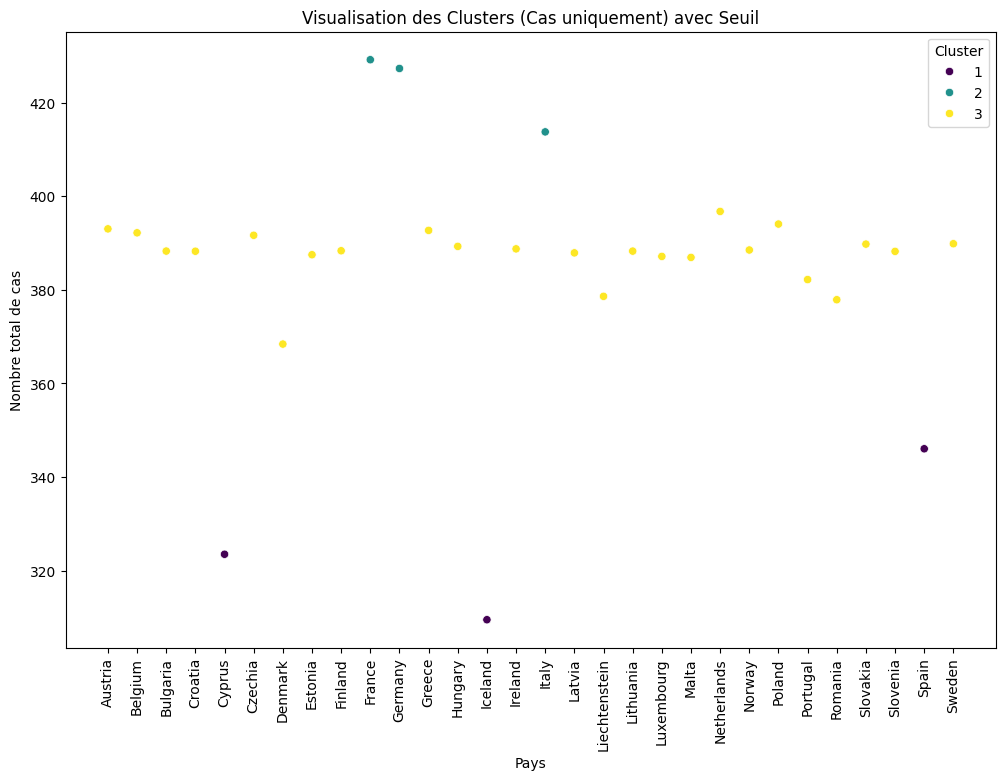

Cluster 3: {Austria, Belgium, Bulgaria, Croatia, Czechia, Denmark, Estonia, Finland, Greece, Hungary, Ireland, Latvia, Liechtenstein, Lithuania, Luxembourg, Malta, Netherlands, Norway, Poland, Portugal, Romania, Slovakia, Slovenia, Sweden}
Cluster 1: {Cyprus, Iceland, Spain}
Cluster 2: {France, Germany, Italy}


In [57]:
# Calcul de la matrice de liaison pour les cas
linkage_matrix_cases = linkage(country_totals[['total_cases']], method='ward')

# Détermination des clusters avec un seuil (moitié du maximum des distances pour les cas)
max_distance_cases = linkage_matrix_cases[:, 2].max()  # Distance maximale dans le dendrogramme pour les cas
seuil_cases = max_distance_cases / 2
clusters_cases = fcluster(linkage_matrix_cases, t=seuil_cases, criterion='distance')

# Ajouter les clusters aux données (basé sur les cas)
country_totals['cluster_cases'] = clusters_cases

# Visualiser les clusters des cas dans un diagramme nuageux
plt.figure(figsize=(12, 8))
sns.scatterplot(x='countriesAndTerritories', y='total_cases', hue='cluster_cases', data=country_totals, palette='viridis')
plt.title("Visualisation des Clusters (Cas uniquement) avec Seuil")
plt.xlabel("Pays")
plt.xticks(rotation=90)
plt.ylabel("Nombre total de cas")
plt.legend(title='Cluster')
plt.show()

# Afficher les pays de chaque cluster dans le format souhaité
clusters = country_totals['cluster_cases'].unique()
cluster_dict = {}

for cluster in clusters:
    countries_in_cluster = country_totals[country_totals['cluster_cases'] == cluster]['countriesAndTerritories'].tolist()
    cluster_dict[f"Cluster {cluster}"] = ', '.join(countries_in_cluster)

for cluster, countries in cluster_dict.items():
    print(f"{cluster}: {{{countries}}}")


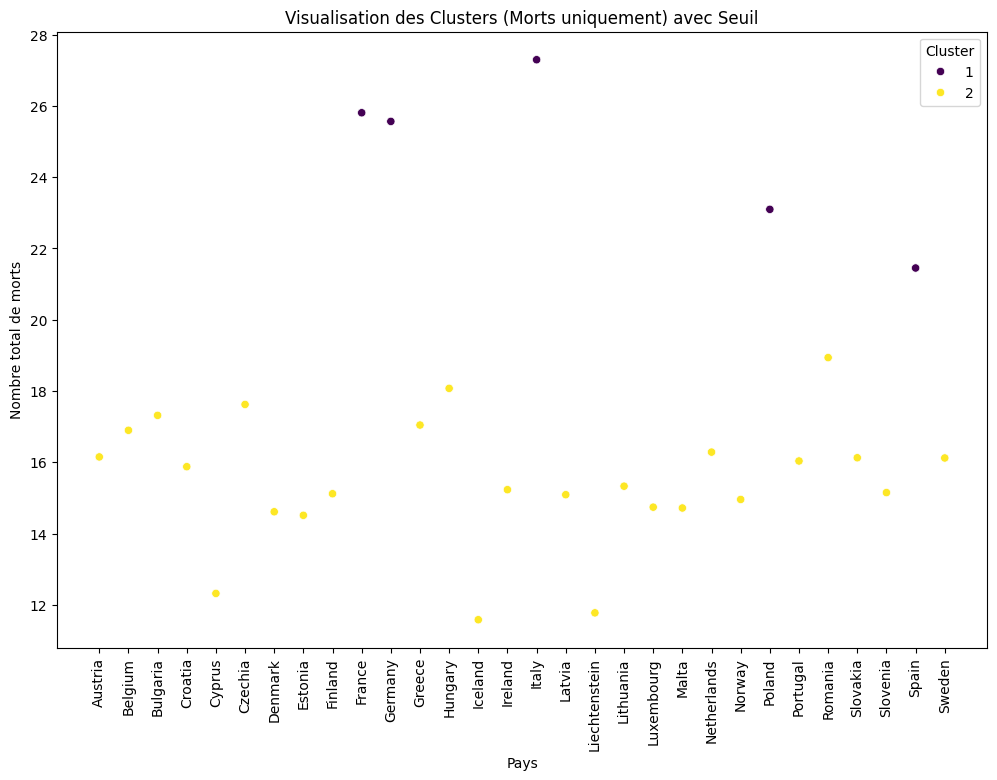

Cluster 2: {Austria, Belgium, Bulgaria, Croatia, Cyprus, Czechia, Denmark, Estonia, Finland, Greece, Hungary, Iceland, Ireland, Latvia, Liechtenstein, Lithuania, Luxembourg, Malta, Netherlands, Norway, Portugal, Romania, Slovakia, Slovenia, Sweden}
Cluster 1: {France, Germany, Italy, Poland, Spain}


In [42]:
# Calcul de la matrice de liaison pour les morts
linkage_matrix_deaths = linkage(country_totals[['total_deaths']], method='ward')

# Détermination des clusters avec un seuil (moitié du maximum des distances pour les morts)
max_distance_deaths = linkage_matrix_deaths[:, 2].max()  # Distance maximale dans le dendrogramme pour les morts
seuil_deaths = max_distance_deaths / 2
clusters_deaths = fcluster(linkage_matrix_deaths, t=seuil_deaths, criterion='distance')

# Ajouter les clusters aux données (basé sur les morts)
country_totals['cluster_deaths'] = clusters_deaths

# Visualiser les clusters des morts dans un diagramme nuageux
plt.figure(figsize=(12, 8))
sns.scatterplot(x='countriesAndTerritories', y='total_deaths', hue='cluster_deaths', data=country_totals, palette='viridis')
plt.title("Visualisation des Clusters (Morts uniquement) avec Seuil")
plt.xlabel("Pays")
plt.xticks(rotation=90)
plt.ylabel("Nombre total de morts")
plt.legend(title='Cluster')
plt.show()

# Afficher les pays de chaque cluster dans le format souhaité
clusters = country_totals['cluster_deaths'].unique()
cluster_dict = {}

for cluster in clusters:
    countries_in_cluster = country_totals[country_totals['cluster_deaths'] == cluster]['countriesAndTerritories'].tolist()
    cluster_dict[f"Cluster {cluster}"] = ', '.join(countries_in_cluster)

for cluster, countries in cluster_dict.items():
    print(f"{cluster}: {{{countries}}}")



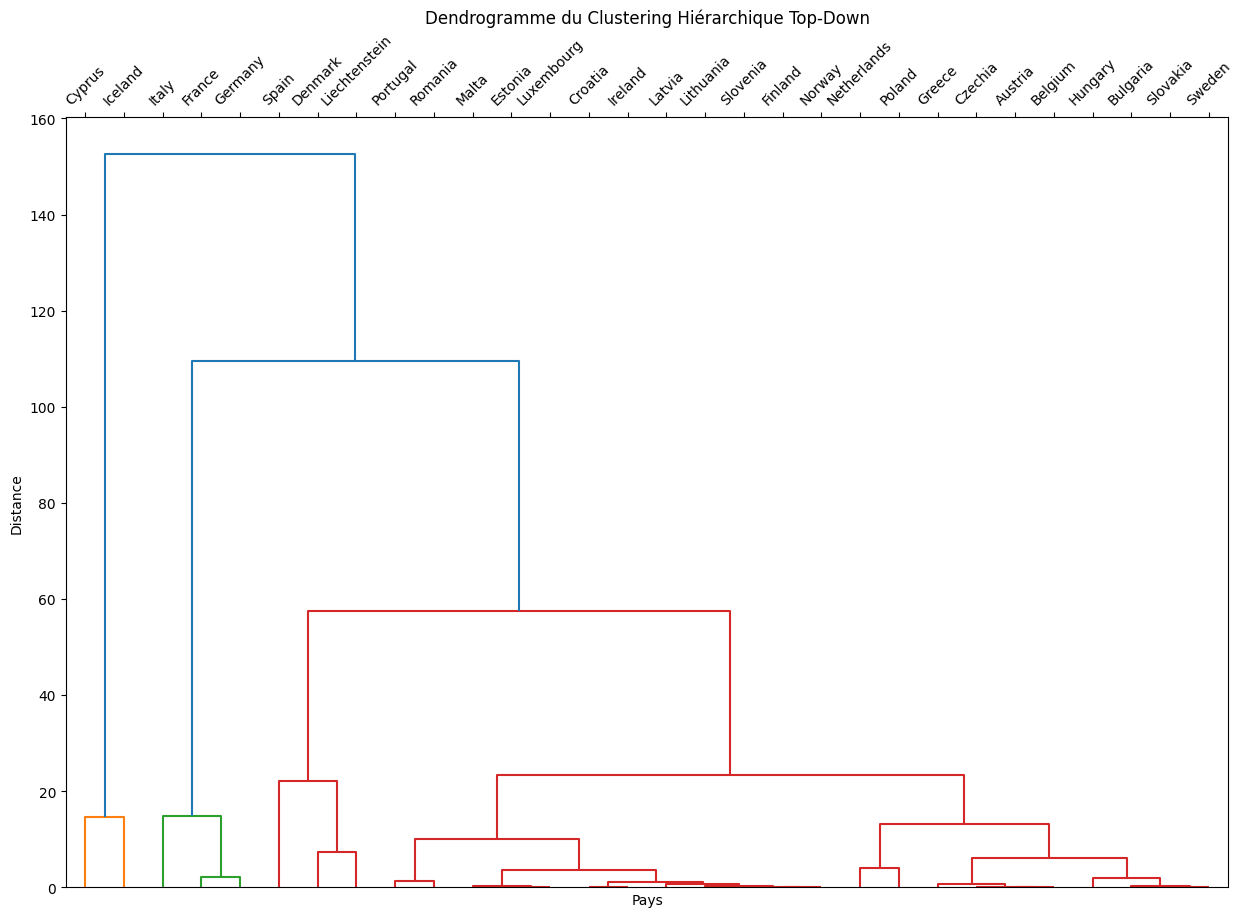

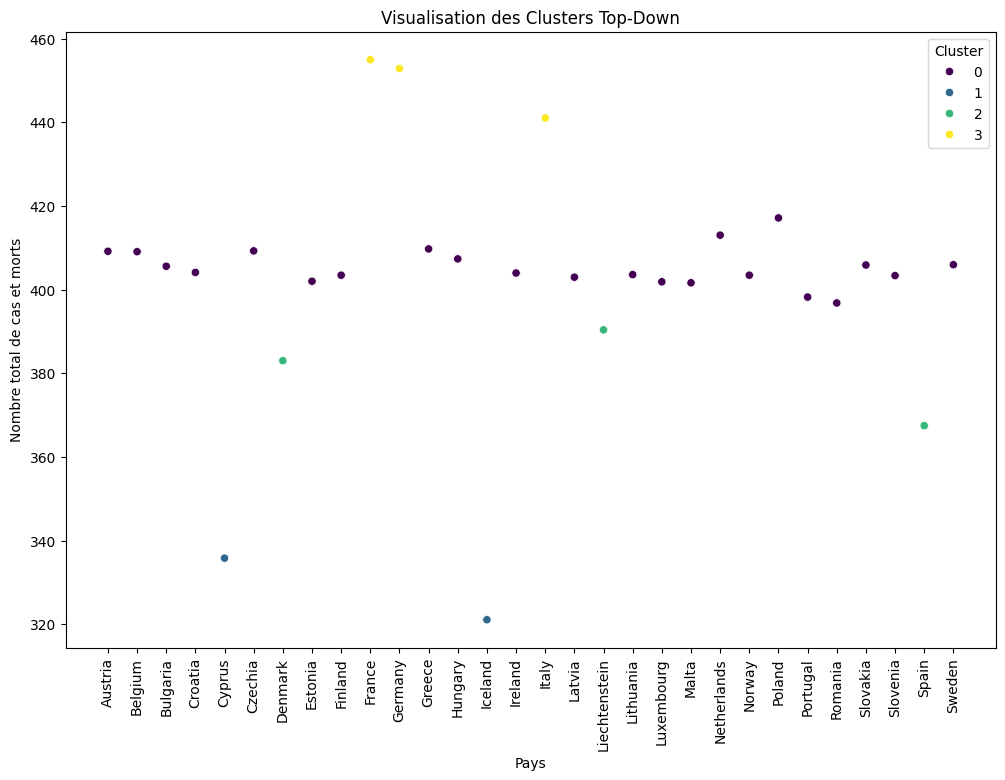

Cluster 0: {Austria, Belgium, Bulgaria, Croatia, Czechia, Estonia, Finland, Greece, Hungary, Ireland, Latvia, Lithuania, Luxembourg, Malta, Netherlands, Norway, Poland, Portugal, Romania, Slovakia, Slovenia, Sweden}
Cluster 1: {Cyprus, Iceland}
Cluster 2: {Denmark, Liechtenstein, Spain}
Cluster 3: {France, Germany, Italy}


In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree

# Visualisation du dendrogramme
plt.figure(figsize=(15, 10))
dendrogram(linkage_matrix, labels=country_totals['countriesAndTerritories'].values)
plt.title("Dendrogramme du Clustering Hiérarchique Top-Down")
plt.xlabel("Pays")
plt.ylabel("Distance")
ax = plt.gca()
ax.xaxis.tick_top()
plt.show()


# Découpage de l'arbre pour obtenir les clusters (par exemple, 4 clusters)
n_clusters = 4
clusters = cut_tree(linkage_matrix, n_clusters=n_clusters).flatten()

# Ajouter les clusters aux données
country_totals['cluster'] = clusters

# Visualiser les clusters dans un diagramme nuageux
plt.figure(figsize=(12, 8))
sns.scatterplot(x='countriesAndTerritories', y='cases_deaths_sum', hue='cluster', data=country_totals, palette='viridis')
plt.title("Visualisation des Clusters Top-Down")
plt.xlabel("Pays")
plt.xticks(rotation=90)
plt.ylabel("Nombre total de cas et morts")
plt.legend(title='Cluster')
plt.show()

# Afficher les pays de chaque cluster dans le format souhaité
clusters = country_totals['cluster'].unique()
cluster_dict = {}

for cluster in clusters:
    countries_in_cluster = country_totals[country_totals['cluster'] == cluster]['countriesAndTerritories'].tolist()
    cluster_dict[f"Cluster {cluster}"] = ', '.join(countries_in_cluster)

for cluster, countries in cluster_dict.items():
    print(f"{cluster}: {{{countries}}}")